# OGS Community Meeting 2026: Tutorial of a simple real World GW-Model for the Selke River Catchment

**Authors:** Erik Nixdorf $^1$, Niklas Ritter $^2$, Tobias Meisel $^2$, Linus Walter $^2$

$^1$ Faculty of Environmental Sciences, Technical University Dresden, Helmholtzstr. 10, 01069 Dresden, Germany \
$^2$ Department of Environmental Informatics, Helmholtz Centre for Environmental Research, Permoserstr. 15, 04318 Leipzig, Germany


**Linktree**
* [OGS Website](https://www.opengeosys.org/stable/)
* [OGSTools Website](https://ogstools.opengeosys.org/stable/)


## 0. Problem Statement: The Slope Failure Event of Nachterstedt 

On 18 July 2009, a landslide at Nachterstedt was probably triggered by soil liquefaction during the flooding of a former lignite open-cast mine.
Around 2.2 million cubic metres of earth broke away and slid into the newly formed lake.

<figure>
	<img src="https://img.sparknews.funkemedien.de/221047585/221047585_1436969400_v16_9_1600.webp" width="80%">
</figure>

---

<figure>
	<img src="https://img.sparknews.funkemedien.de/221047783/221047783_1436969400_v16_9_1600.webp" width="80%">
</figure>

---

<figure>
	<img src="https://img.sparknews.funkemedien.de/221047713/221047713_1436969400_v16_9_1600.webp" width="80%">
</figure>


Source: TLZ (2015). Sechs Jahre nach dem Erdrutsch in Nachterstedt. https://www.tlz.de/leben/natur-umwelt/article221047525/Sechs-Jahre-nach-dem-Erdrutsch-in-Nachterstedt.html

Optional: View lake via [Google Maps](https://www.google.com/maps/place/Nachterstedt,+Seeland/@51.809118,11.3326054,5541m/data=!3m2!1e3!4b1!4m6!3m5!1s0x47a5bfcd2823558b:0xa23665c8824e3a0!8m2!3d51.8008301!4d11.3337974!16s%2Fm%2F03c1b66!5m1!1e2?entry=ttu&g_ep=EgoyMDI2MDkxNi4wIKXMDSoASAFQAw%3D%3D)


## Checkin: Let's match our Experiences and Expectations about the Tutorial

**Target Group:** \
This tutorial is made (hydro-)geologists or (geo-)engineers with no, or only slight experience in OpenGeoSys.

**Objectives:** \
The main objective of this notebook is to model a stationary groundwater model on a real-world dataset in OGS.
In particular, we show how to 
1. build an OpenGeoSys model
2. run the computation
3. analyse the results by using the `ogstools` Python-library (Example [workflow](https://ogstools.opengeosys.org/stable/auto_examples/howto_quickstart/plot_framework.html)). 

In addition to the parameterisation of a base model, the participants learn how to assign a periodic groundwater recharge and to alter the water level of Lake Condordia.

**Questions:**
1. Which experience to you have with OGS and OGS Tools?
2. What are your expectations for today's workwhop?

## 1. Exploring the Dataset of the Selke River
The River Selke is a fourth-order stream with a length of 64 km draining a part of the forested Harz Mountains and the agriculturally dominated Northern Harz foreland in Central Germany. Due to different water management targets such as the design of infiltration wells along a former pit mine the area is of particular interest for hydrogeological research (Zhang et al., 2021; Nixdorf et al., 2025; see [Reference List](#references)).

#### Zhang et al. (2021): First Complex Hydraulic Model

<figure>
	<img src="figures/zhang2021fig1.jpg" width="100%">
</figure>


#### Nixdorf et al. (2025): Simplification and Layer Reduction

* Combined approach, leveraging expert knowledge to simplify stratigraphy and analyse changes in geohydraulic simulation outputs
* Workflow of open-source tools: Stratmerge (stratification) and simulator OGS


<figure>
	<img src="figures/nixdorf2025fig4.jpg" width="100%">
</figure>


* Definition of boundary conditions (rivers, catchment, groundwater recharge)
* Aquifer properties (distribution)
* Hydraulic influence of former open pit mining 
<figure>
	<img src="figures/selke02.png" width="80%">
</figure>




### 1.1 Loading the Data

In [31]:
import numpy as np
import ogstools as ot
import pyvista as pv
from matplotlib import pyplot as plt

ot.plot.setup.show_region_bounds = False
ot.plot.setup.continuous_cmap = True  # continuous colormap shading instead of discrete bins, for all contourf plots below

In [32]:
# Load Meshes
input_meshes = [
    "Selke_Basin_Domain_homo.vtu",
    "Selke_Basin_PG_Concordia.vtu",
    "Selke_Basin_PG_Koenigsauer.vtu",
    "Selke_Basin_PG_Wilsleber.vtu",
    "Selke_Basin_PL_Bode.vtu",
    "Selke_Basin_PL_Wipper.vtu",
    "Selke_Basin_Pnt_Wells.vtu",
    "Selke_Basin_PL_Selke.vtu",
]
meshes = ot.Meshes.from_files(input_meshes)
output_names_dict = {
    "Selke_Basin_Domain_homo": "Selke Basin",
    "Selke_Basin_PG_Concordia": "Lake Concordia",
    "Selke_Basin_PG_Koenigsauer": "Lake Königsauer",
    "Selke_Basin_PG_Wilsleber": "Lake Wilsleber",
    "Selke_Basin_PL_Bode": "River Bode",
    "Selke_Basin_PL_Wipper": "River Wipper",
    "Selke_Basin_Pnt_Wells": "Pumping Wells",
    "Selke_Basin_PL_Selke": "River Selke",
}
meshes.rename_output_names(output_names_dict)

### 1.2 Visualising the Topology
`ogstools` includes native functionality to visualise the domain mesh and all submeshes in one image. \
For simplicity, the geometry is projected onto the X-Y-surface. To see the height values included in the domain meshes we have to fall back on pyvista.

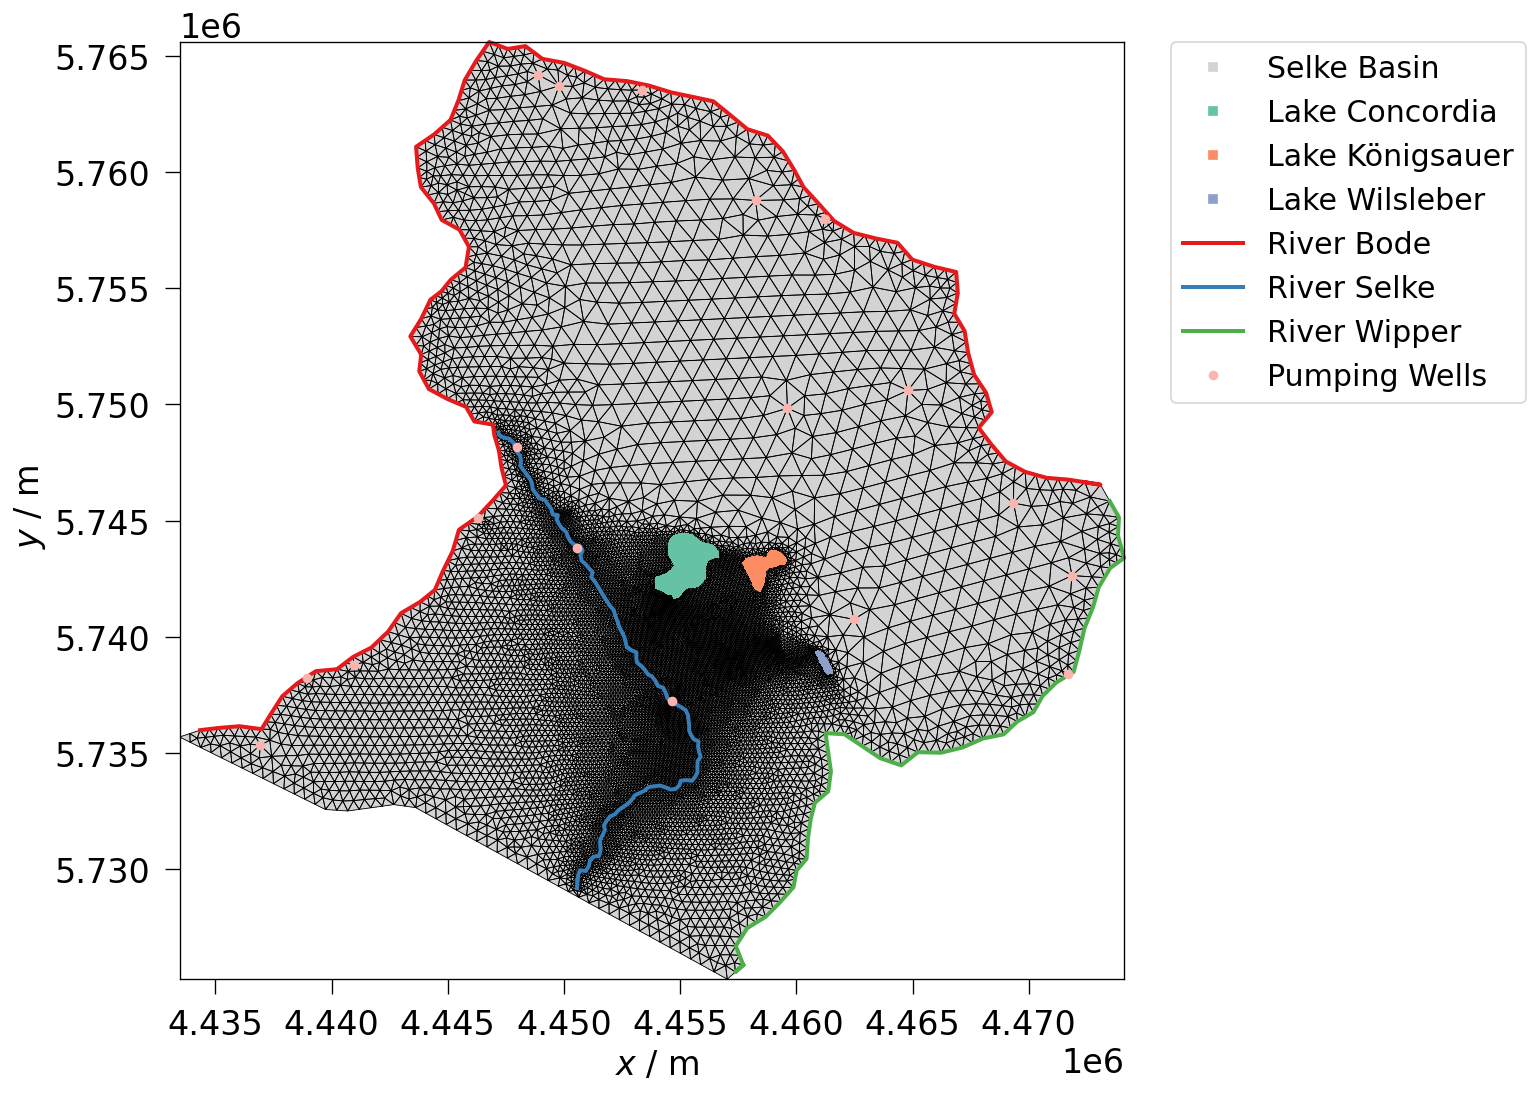

In [33]:
# Visualise meshes via ogstools
fig_topology = meshes.plot(fontsize=20, lw=0.6)

In addition, the 3D geometry can be explored through the PyVista Viewer:

In [34]:
transform = pv.Transform()
# Define the vertical scaling factor in z:
transform.scale(1, 1, 10)
pl = pv.Plotter()
pl.add_mesh(meshes["Selke_Basin_Domain_homo"].transform(transform, inplace=False),opacity=0.6, label="Selke Basin")
pl.add_mesh(meshes["Selke_Basin_PG_Concordia"].transform(transform, inplace=False),label="Lake Concordia", color="turquoise_blue")
pl.add_mesh(meshes["Selke_Basin_PG_Koenigsauer"].transform(transform, inplace=False),label="Lake Koenigsauer", color="orange")
pl.add_mesh(meshes["Selke_Basin_PL_Selke"].transform(transform, inplace=False), label="River Selke", color="blue")

pl.add_legend()
pl.show()

Widget(value='<iframe src="http://localhost:38557/index.html?ui=P_0x78bee05ec680_2&reconnect=auto" class="pyvi…

### 1.3 📯 Task: Add Lake Wilsleber
Currently, we have a 3D visualisation of the Selke Basin, Lake Concordia, Lake Königsauer, and River Selke.
Now, add Lake Wilsleber to the visualisation.


## 2. Theoretical Background: The Liquid Flow Process in OGS

For representing groundwater, we use the `LiquidFlow`-Process in OGS. 
The `LiquidFlow`-Process models saturated single-phase flow, which can be of variable density, in porous and fractured media.
In the context of groundwater modelling, it is important to note that the pressure-based variant of the groundwater flow equation is implemented in OGS, which may not be the most intuitive for hydrogeologists. At the end of this notebook, we will also provide a conversion between the pressure-based and the hydraulic-head based formulations.

For assuming the groundwater to be incompressible (e.g.,  $\partial \rho_w / \partial p_w \equiv 0$), the volume balance as the main governing equation writes as:

$$
\beta_s \frac{\partial p_w}{\partial t}  -\nabla \cdot \left(\frac{\mathbf{K}_0}{\mu_w} \left( \nabla p_w - \rho_w \mathbf{g} \right)\right) = W_0 \qquad \left[ \mathrm{\frac{1}{s}} \right]\,,
$$
where the subscript $w$ denotes "water". Please note that the specific storage coefficient in OGS $\beta_s$ can be computed from the one generally used in hydrogeology, $S_0$, through:

$$
\beta_s = \frac{1}{\rho_\text{w}\, g} S_{0} \quad  \mathrm{[\mathrm{Pa^{-1}}]} 
$$

The Darcy velocity as secondary variable writes as:

$$
\mathbf{q} = - \frac{\mathbf{K_0}}{\mu_w} \left( \nabla p_w - \rho_w \mathbf{g} \right)  \qquad \left[ \mathrm{\frac{m}{s}} \right] \, .
$$

The following table lists all variables used in the equations:

| Symbols | Units | SI | Definition |
| ---: | --- | --- | --- |
| $\beta_s$ | [LT²/M] | [1/Pa] | specific storage coefficient of OGS |
| $\mu_w$ | [M/LT] | [Pa s] | dynamic fluid viscosity |
| $\rho_w$ | [M/L³] | [kg/m³] | fluid density |
| $\nabla$ | [1/L] | [1/m] | divergence, gradient operator |
| $g$ | [L/T²] | [m/s²] | gravitational acceleration coefficient |
| $\mathbf{g}$ | [L/T²] | [m/s²] | gravitational acceleration vector (0,0,g) |
| $\mathbf{K_0}$ | [L²] | [m²] | intrinsic permeability |
| $n_e$ | [-] | [-] | effective porosity |
| $p_w$ | [M/LT²] | [Pa] | water pressure |
| $S_0$ | [1/M] | [1/m] | specific storage in hydrogeology |
| $t$ | [T] | [s] | time |
| $W_0$ | [1/T] | [1/s] | source/sink term |

See the detailed [process description](https://ogs.ogs.xyz/ogs/docs/processes/liquid-flow/liquidflow/) of the `LiquidFlow`-process.

## 3. Setting up an OGS Model

An OGS Model is parameterized with a project file, indicated by the file ending `.prj`.
The project file defines all necessary ingredients to run the model:

```mermaid
flowchart LR
    A[Meshes] -->|"Linked"| D["OGS Project File<br>(.prj)"]
    AA[Governing Processes] -->|"Defined"| D["OGS Project File<br>(.prj)"]
    B[Material Parameters] -->|"Defined"| D["OGS Project File<br>(.prj)"]
    C["Initial Condition / <br> Boundary Conditions / <br> Sources Sinks"] -->|"Defined"| D["OGS Project File<br>(.prj)"]
    D["OGS Project File<br>(.prj)"] --> E[OGS Simulation] --> F["Visualization <br> of Results"]
```

The relevant meshes are linked in the section `<meshes>`, the physical processes (e.g., the `LiquidFlow` process) are defined in `<processes>`, and the required material parameters are defined in `<media>`. Initial condition, boundary conditions and source terms can be defined for each process variable in `<process_variables>`.


**Structure of the Project File:**
```xml
<?xml version="1.0" encoding="ISO-8859-1"?>
<OpenGeoSysProject>
    <meshes> 
  	...
    </meshes>
    <processes>
		...
    </processes>
    <media>
		...
    </media>
    <parameters>
		...
    </parameters>
    <process_variables>
		...
    </process_variables>
    <time_loop>
		...
    </time_loop>
	...
</OpenGeoSysProject>
```

See more details in the [introduction to the project file](https://ogs.ogs.xyz/ogs/docs/userguide/basics/project_file_intro/).


In [35]:
# Load project file
prj_base = ot.Project("Selke_Basin.prj").copy()

# Optional: Configure execution settings, e.g.
# model_base.execution.interactive = True # Uncomment for stepwise control

### 3.1 Setting Material Parameters

We adopt the material parameters for the model of the Selke basin based on [Nixdorf et al., 2025](#references):

|            | Symbol          | Value                | SI                    |
| ---------: | ---------------: | -------------------- | --------------------- |
| **Liquid** | $\mu$           | $0.0011373$          | $\mathrm{Pa\,s}$      |
|            | $\rho_\text{w}$ | $1000$               | $\mathrm{kg\,m^{-3}}$ |
|  **Solid** | $K_0$           | $5.8\times 10^{-10}$ | $\mathrm{m^{2}}$      |
|            | $n_{e}$         | $0.17$               | -                     |
|            | $\beta_{0}$     | $0$                  | $\mathrm{Pa^{-1}}$    |

Please note that $\beta_{0}$ is set to zero to obtain a stationary model.
We set these material parameters within `prj_base` as follows:

In [36]:
# Parameters for Water
prj_base.replace_phase_property_value(0,name="viscosity",value=1.1373e-3)
prj_base.replace_phase_property_value(0,name="density",value=1000)
# Parameters for Porous Medium
prj_base.replace_medium_property_value(0,name="permeability",value=5.8e-10)
prj_base.replace_medium_property_value(0,name="porosity",value=0.17)
prj_base.replace_medium_property_value(0,name="storage",value=0)

### 3.2 Boundary Conditions: The Water Level of Lake Concordia Lies 19 m Below the Surrounding Groundwater
Next we create a modelling object that combines the project file and the meshes:

<!-- **TODO:** Define the BC of the lakes and rivers within OGStools instead of just loading the results. -->

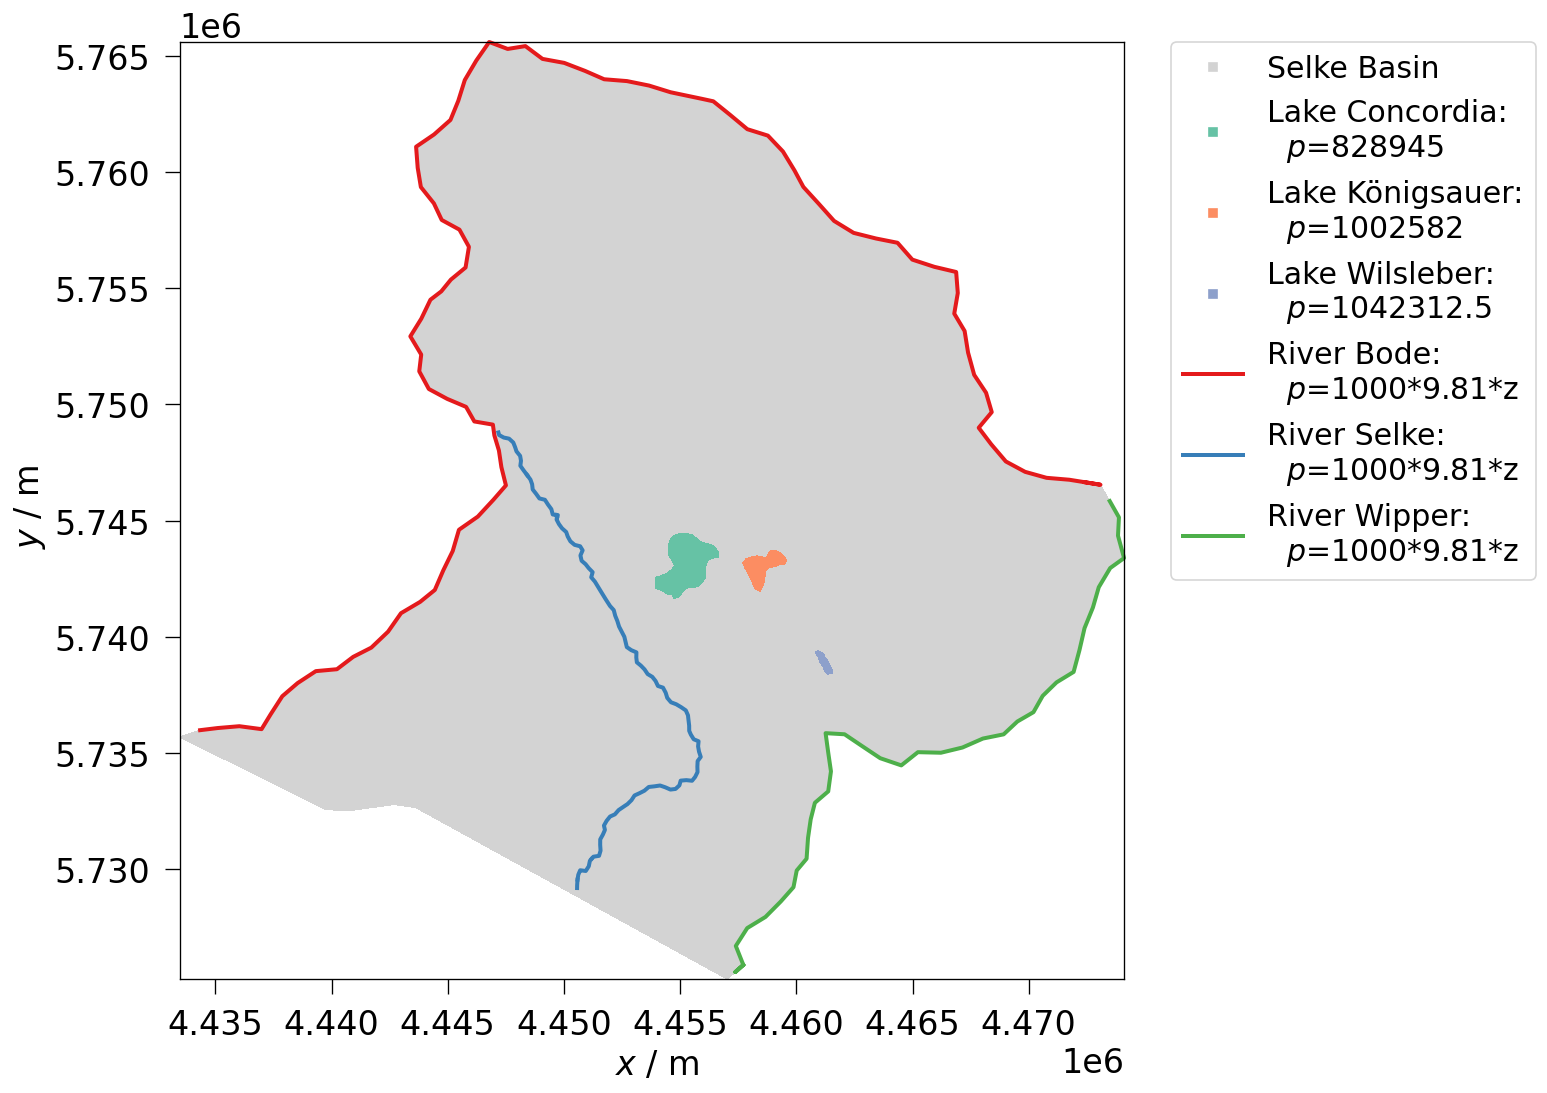

In [37]:
# Visualize boundary conditions
model_base = ot.Model(project=prj_base, meshes=meshes)
fig_constraints = model_base.plot_constraints(fontsize=20, show_edges=False, lw=0.6)

### 3.3 📯 Task: Calculate and Assign Groundwater Recharge

For the base model, we assume an annual groundwater recharge of $100 \mathrm{mm/y}$.

Let's calculate `q_recharge` in $\mathrm{[m^{3}/(m^2\,s)]}$. 

<!-- q_recharge = 3.19e-9 -->

In [ ]:
q_recharge = ???

prj_base.parameters.add_parameter(name="q_recharge", type="Constant", value=q_recharge)
prj_base.process_variables.add_st(
    process_variable_name="pressure",
    type="Volumetric",
    mesh="Selke_Basin_Domain_homo",
    parameter="q_recharge",
)

### 3.4 Define Timesteps
We let the model run for one year with one timestep per month:

In [39]:
t_year = int(365*24*3600)
t_month = int(t_year/12)
prj_base.time_loop.set_stepping(type="FixedTimeStepping",process="LiquidFlow",
                                t_initial=1,t_end=t_year, repeat = 12, delta_t = t_month)

In [40]:
prj_base.save(target=".", overwrite=True)

[PosixPath('default.prj')]

## 4. Run Simulation
Running the simulation is now just as easy.


In [41]:
sim_base = model_base.run(target="sim_base", overwrite=True)
# Optional: Check simulation status (i.e. if the simulation was successful)
print(f"Simulation status: {sim_base.status_str}")

Simulation status: Status: completed successfully (results available)


## 5. Analysing Results
The results of the modelling process can be accessed through `sim_base.meshseries`.\
`ogstools` already has some functions to further analyse the model output, allowing us to both see the process variables on the whole domain at any given time and to show the changes at a single point over the whole simulation interval.\
Before we start plotting our results, we rescale the resulting meshseries from SI units into more readable ones.

In [42]:
sim_base.meshseries.scale(spatial="km", time="d")

MeshSeries(filepath='/tmp/ogstools_walterli/MeshSeries/20260921_223417_462507/default.pvd', spatial_unit='km', time_unit='d')
StorageBase(id='20260921_223417_462507', is_saved=False, _active_target=None, next_target=PosixPath('/tmp/ogstools_walterli/MeshSeries/20260921_223417_462507/default.pvd'))
data_type='.pvd'
num_timesteps=13
dim=2
cached_meshes=1

### 5.1 Visualise Final State
The example below shows hydraulic head at the last point of the simulation interval.
Since we carried out the simulation using pressure as the process variable, we first have to create a new field containing the hydraulic head at each point.\
Afterwards, we simply extract the mesh at our chosen time and plot it with the desired variable.

`ogstools` has no built-in option to overlay isolines on a `contourf` plot (the only related global setting is `setup.continuous_cmap` above). The small helper below reconstructs the same triangulated field that `ot.plot.contourf()` uses internally and draws matplotlib contour lines on top of it, so we can reuse it after every contourf call instead of repeating this logic.

In [43]:
from matplotlib.tri import Triangulation
from ogstools.plot import utils as ot_plot_utils
from ogstools.variables import Variable


def add_isolines(mesh, variable, ax, num_levels=10, color="0.2", linewidth=0.8):
    """Overlay isolines on an existing ot.plot.contourf() axis.

    Note: unlike ot.plot.contourf(), this does not honour logscale=True;
    isolines are always computed on the raw (linear) field values.
    """
    variable = Variable.find(variable, mesh)
    surf_tri = mesh.triangulate().extract_surface(algorithm="dataset_surface")
    surf_tri = surf_tri.extract_cells_by_type(pv.CellType.TRIANGLE)
    x_id, y_id, _, _ = ot_plot_utils.get_projection(mesh)
    x, y = surf_tri.points.T[[x_id, y_id]]
    tri = surf_tri.faces.reshape((-1, 4))[:, 1:]
    values = variable.magnitude.transform(surf_tri)
    triangulation = Triangulation(x, y, tri)
    return ax.tricontour(
        triangulation, values, levels=num_levels, colors=color, linewidths=linewidth
    )




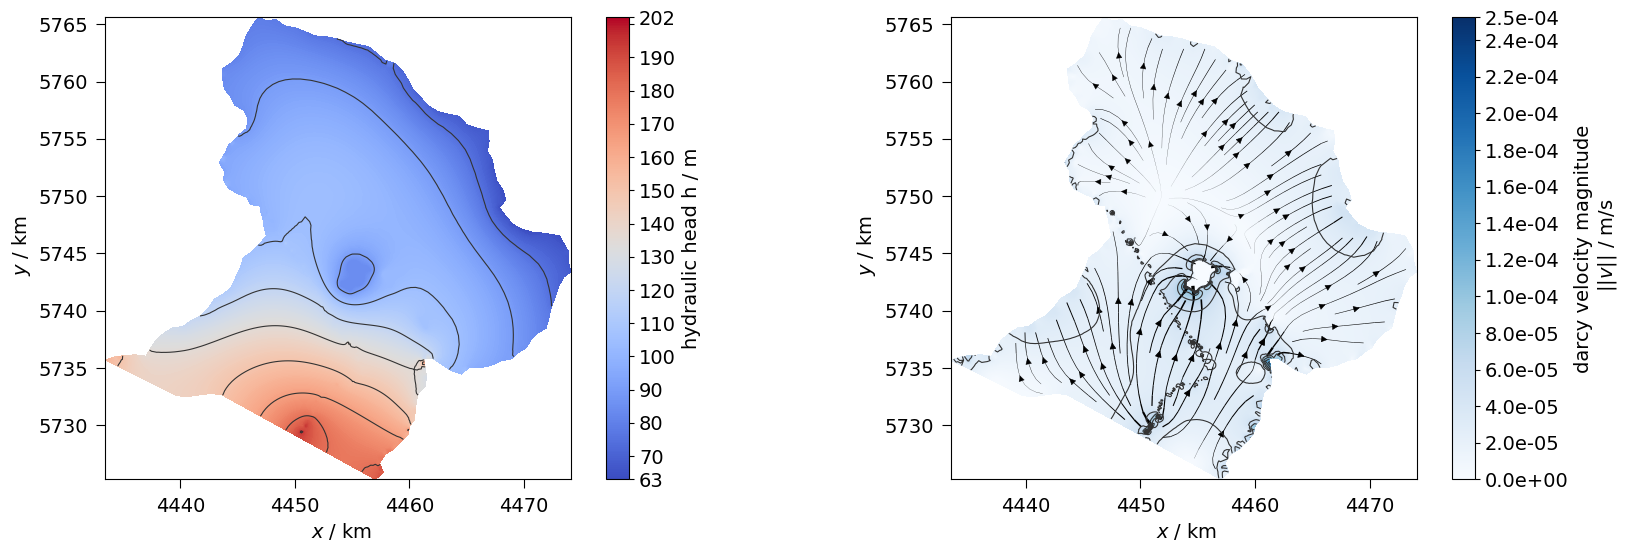

In [44]:
sim_base.meshseries.point_data["hydraulic head h / m"] = sim_base.meshseries.point_data["pressure"] / (1000 * 9.81)
velocity = ot.variables.velocity.replace(data_name="v")

fig, axs = plt.subplots(1, 2, figsize=(20, 6))
ot.plot.contourf(sim_base.meshseries[-1], "hydraulic head h / m", fontsize=14, fig=fig, ax=axs[0],cbar=True)
add_isolines(sim_base.meshseries[-1], "hydraulic head h / m", axs[0])
ot.plot.contourf(sim_base.meshseries[-1], velocity, fontsize=14, logscale=True, fig=fig, ax=axs[1], cbar=True)
add_isolines(sim_base.meshseries[-1], velocity, axs[1])

In [1]:
transform = pv.Transform()
# Define the vertical scaling factor in z:
transform.scale(1, 1, 10)
pl = pv.Plotter()
pl.add_mesh(sim_base.meshseries[-1].transform(transform, inplace=False), scalars="hydraulic head h / m", opacity=0.6,cmap="coolwarm")
pl.show()

NameError: name 'pv' is not defined

## 6. Parameter Study: Switching towards Seasonal Groundwater Recharge

Now we change the groundwater recharge for the whole Selke Basin from constant to seasonal by applying a cosine function. We assume the highest recharge in winter and the lowest in summer:

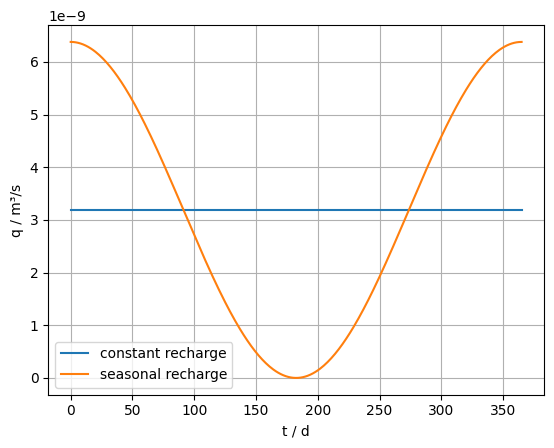

In [46]:
seconds_per_year = 31536000
t_year = np.linspace(0, seconds_per_year, 366, dtype=int)
q_year_scale = np.cos(2 * np.pi * t_year / seconds_per_year)+1

# ################################
# Plotting Comparison curves
# ################################
plt.plot(t_year/24/3600, np.ones(t_year.shape)*q_recharge,label="constant recharge")
plt.plot(t_year/24/3600, q_year_scale*q_recharge, label="seasonal recharge")
plt.grid()
plt.xlabel("t / d")
plt.ylabel("q / m³/s")
plt.legend()
plt.show()

In [47]:
prj_recharge = prj_base.copy()
prj_recharge.curves.add_curve(name="curve_recharge", 
                              coords=t_year.tolist(), 
                              values=q_year_scale.tolist())
prj_recharge.parameters.set_curve_scaled_parameter(
    name="q_recharge_scaled",
    curve="curve_recharge",
    parameter="q_recharge"
)
prj_recharge.replace_text(
    value="q_recharge_scaled",
    xpath="./process_variables/process_variable/source_terms/source_term/parameter")

In [48]:
model_recharge = ot.Model(project=prj_recharge, meshes=meshes)
sim_recharge = model_recharge.run(target="sim_recharge", overwrite=True)
sim_recharge.meshseries.scale(spatial="km", time="d")
sim_recharge.meshseries.point_data["hydraulic head h / m"] = sim_recharge.meshseries.point_data[
    "pressure"
] / (1000 * 9.81)

### 5.2 Visualise Process at Single Point
To do this, we first define the coordinates of our chosen observation point.\
To check that we have chosen the correct coordinates, we can plot the point into the meshes.\
After that, we extract the process variables for all times at the given point from the resulting meshseries using `probe()`.\
Finally, we plot the extracted data as a line graph.\
The example below shows the hydraulic head at x=4456.313 km, y=5734.965 km.

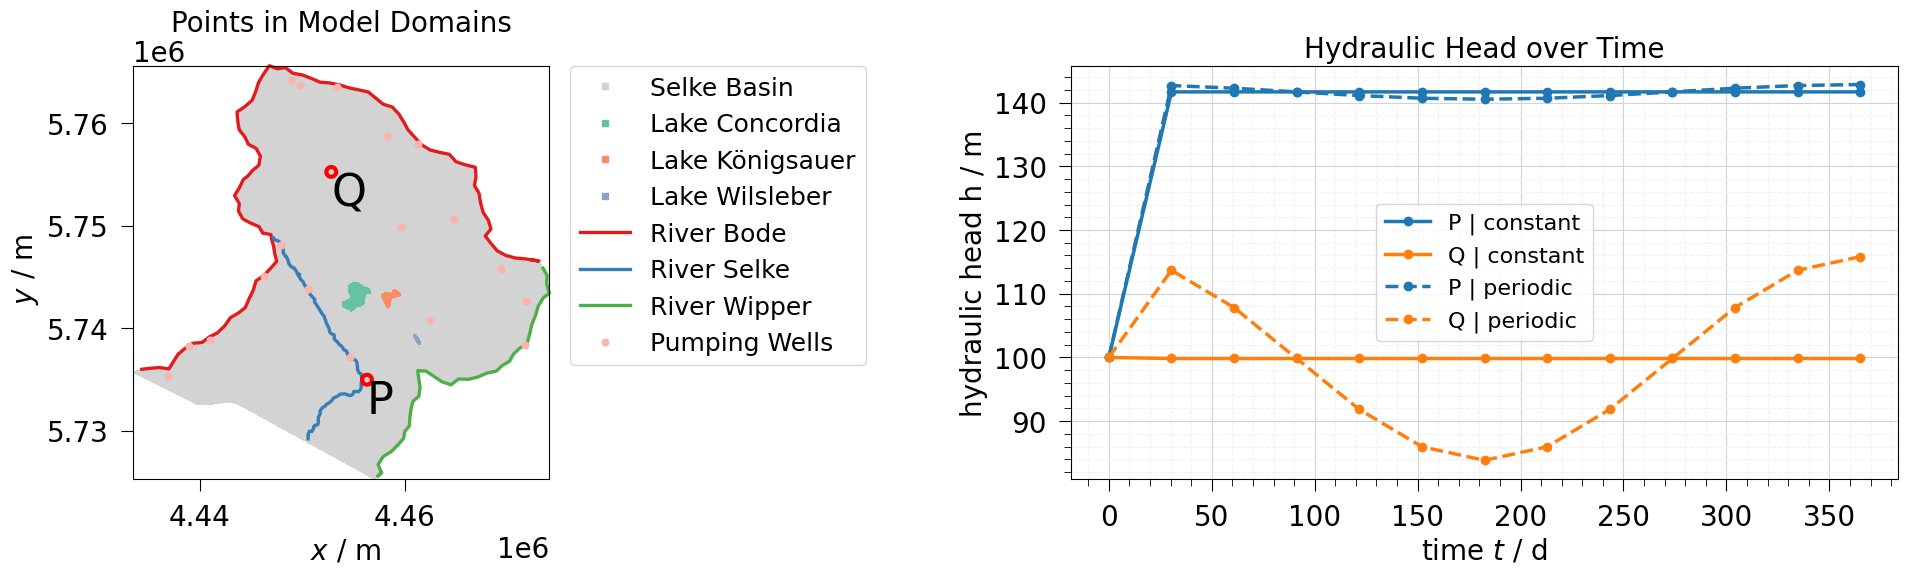

In [49]:
# Define points
point_P = (4456.313, 5734.965, 0.151)
point_Q = (4452.826, 5755.238, 0.153)
# Extract data from model with constant recharge
probes_base = sim_base.meshseries.probe(np.array([point_P, point_Q]))
# Extract data from model with constant recharge
probes_recharge = sim_recharge.meshseries.probe(np.array([point_P, point_Q]))

 # ################################
# Plotting
# ################################
fig, axs = plt.subplots(1, 2, figsize=(20,6))
meshes.plot(fontsize=20,show_edges=False, lw=0.6, fig = fig, ax=axs[0])
axs[0].scatter(
    [point_P[0] * 1000, point_Q[0] * 1000],
    [point_P[1] * 1000, point_Q[1] * 1000],
    s=50,fc="none",ec="r",lw=3,zorder=2
    )
axs[0].annotate("P", (4456313, 5734965), va="top", fontsize=32)
axs[0].annotate("Q", (4452826, 5755238), va="top", fontsize=32)
axs[0].set_title("Points in Model Domains", loc="center")

probes_base.plot_line(
    "hydraulic head h / m", labels=["P | constant","Q | constant"], marker="o",ax=axs[1], figsize=(10,6),
)
probes_recharge.plot_line(
    "hydraulic head h / m", labels=["P | periodic","Q | periodic"], marker="o", ls="--", ax=axs[1], figsize=(10,6)
)
axs[1].set_title("Hydraulic Head over Time", loc="center")
ot.plot.utils.update_font_sizes(axs, fontsize=20)
axs[1].legend(handlelength=2,fontsize=16)
plt.show()

## 7. 📯 Task: Adapting Water Level of Lake Concordia
Lake Concordia has its current water level $19\,\mathrm{m}$ below the actual groundwater level. Within the next 16 years, the water level should slowly raise by $18\mathrm{m}$. Let's 
Let's model the final hydraulic head distrbution of the groundwater in year 2042 and compare it to nowadays:

$$
p_\text{new} = p_\text{old} + \Delta h\,\rho_\text{w}\,g
$$
with $p_\text{old}=828945\mathrm{Pa}$ and $\Delta h=18\,\mathrm{m}$.

<!-- p_new =  828945 + 18*1000*9.81 -->

In [ ]:
p_new =  ???
prj_concordia = prj_recharge.copy()

prj_concordia.replace_parameter(
    name="p_lake_concordia",
    parametertype="Constant",
    taglist=["value"],textlist=[f"{int(p_new)}"]
)
prj_concordia.save(target=".", overwrite=True)

[PosixPath('default.prj')]

In [51]:
model_concordia = ot.Model(project=prj_concordia, meshes=meshes)
sim_concordia = model_concordia.run(target="sim_concordia",overwrite=True)
print(f"Simulation status: {sim_concordia.status_str}")

sim_concordia.meshseries.scale(spatial="km", time="d")
sim_concordia.meshseries.point_data["hydraulic head h / m"] = sim_concordia.meshseries.point_data[
    "pressure"
] / (1000 * 9.81)

Simulation status: Status: completed successfully (results available)


### 7.1 Compute the Model Differences over Space
Having run our additional simulations, we can compute the differences in process variables between two meshseries and plot the results.\
Here we show the difference between the default and the reduced Lake Concordia water level, both under the periodic recharge scenario.

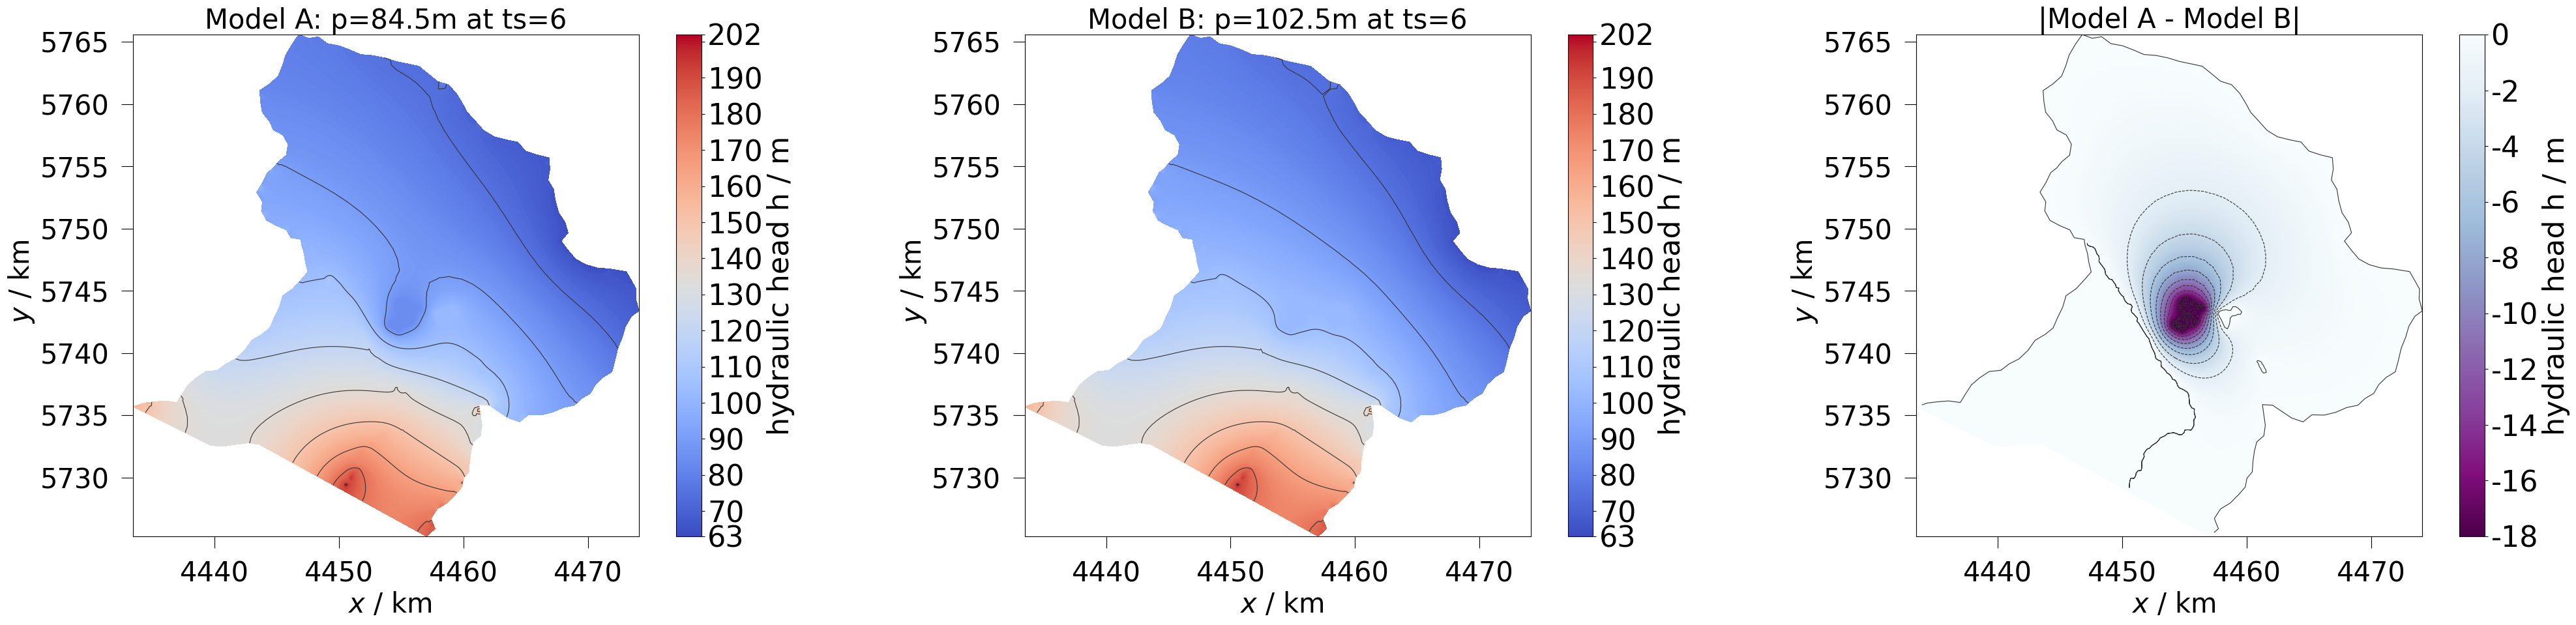

In [59]:
series_diff_concordia = ot.MeshSeries.difference(ms_a=sim_recharge.meshseries, ms_b=sim_concordia.meshseries)
month = 6
variable= "hydraulic head h / m"

# ################################
# Plotting
# ################################
fig, axs = plt.subplots(1, 3, figsize=(50,10))
ot.plot.contourf(sim_recharge.meshseries[month],variable, fig=fig, ax=axs[0])
add_isolines(sim_recharge.meshseries[month], variable, axs[0])
ot.plot.contourf(sim_concordia.meshseries[month],variable, fig=fig, ax=axs[1])
add_isolines(sim_concordia.meshseries[month], variable, axs[1])
ot.plot.contourf(series_diff_concordia[month],variable, fig=fig, ax=axs[2],cmap="BuPu_r")
add_isolines(series_diff_concordia[month], variable, axs[2])

axs[0].set_title(f"Model A: p={828945/1000/9.81:.1f}m at ts={month}")
axs[1].set_title(f"Model B: p={1005525/1000/9.81:.1f}m at ts={month}")
axs[2].set_title(
    r"|Model A - Model B|")
ot.plot.utils.update_font_sizes(axs, fontsize=30)

## AI Outlook (Optional)
Let's tweak a parameter through Claude Code.

<a id='references'></a>
## References

Nixdorf, E., Sips, M., & Morstein, P. (2025). Development of a digital 
workflow for layer reduction strategies and visual-analytical outcome 
analysis to enhance geo-hydraulic modelling efficiency. Digital Water, 
3(1), 1–24. [doi:10.1080/28375807.2025.2460825](https://doi.org/10.1080/28375807.2025.2460825) | [PDF](references/Nixdorf%20et%20al.%20-%202025%20-%20Development%20of%20a%20digital%20workflow%20for%20layer%20reduction%20strategies%20and%20visual-analytical%20outcome%20analy.pdf)


Zhang, Z.-Y., Schmidt, C., Nixdorf, E., Kuang, X., & Fleckenstein, J. H. (2021).
Effects of heterogeneous stream-groundwater exchange on the source composition
of stream discharge and solute load. Water Resources Research, 57, e2020WR029079.
[doi:10.1029/2020WR029079](https://doi.org/10.1029/2020WR029079) | [PDF](references/Zhang%20et%20al.%20-%202021%20-%20Effects%20of%20Heterogeneous%20Stream%E2%80%90Groundwater%20Exchange%20on%20the%20Source%20Composition%20of%20Stream%20Discharge%20a.pdf)

## Archived Content

### Assigning a Robin Boundary Condition

The current Dirichlet boundary conditions we use to characterise the rivers overestimate the groundwater level. \
We therefore want to change the project file to use Robin boundary conditions, which are given by

$$
 Q_{ex}=K\cdot W\cdot L\cdot \frac{h_\text{SW}-h_{GW}}{M}\qquad \left[\mathrm{\frac{m^{3}}{s}}\right]\, ,
$$
where $M$ is the width, $L$ is the length, $M$ is the thickness of the aquifer, $h_\text{SW}$ is the hydraulic head of the surface water, and $h_\text{GW}$ is the hydraulic head of the groundwater.
In OGS, the value $\frac{K\cdot W\cdot L}{M}$ is combined into the single parameter `bed_conductance`.

In [ ]:
project_robin = prj_recharge.copy()

project_robin.parameters.add_parameter(
    name="bed_conductance",
    type="Constant",
    value=5e-9,
)
# We first have to remove the obsolete boundary conditions
project_robin.remove_element(
    ".//boundary_conditions/boundary_condition[mesh='Selke_Basin_PL_Selke']"
)
project_robin.remove_element(
    ".//boundary_conditions/boundary_condition[mesh='Selke_Basin_PL_Wipper']"
)
project_robin.remove_element(
    ".//boundary_conditions/boundary_condition[mesh='Selke_Basin_PL_Bode']"
)
# Now we can re-add the improved boundary conditions
project_robin.process_variables.add_bc(
    process_variable_name="pressure",
    type="Robin",
    mesh="Selke_Basin_PL_Bode",
    u_0="p_rivers",
    alpha="bed_conductance",
)
project_robin.process_variables.add_bc(
    process_variable_name="pressure",
    type="Robin",
    mesh="Selke_Basin_PL_Selke",
    u_0="p_rivers",
    alpha="bed_conductance",
)
project_robin.process_variables.add_bc(
    process_variable_name="pressure",
    type="Robin",
    mesh="Selke_Basin_PL_Wipper",
    u_0="p_rivers",
    alpha="bed_conductance",
)

In [ ]:
model_robin = ot.Model(project=project_robin, meshes=meshes)
sim_robin = model_robin.run(target="sim_robin",overwrite=True)
print(f"Simulation status: {sim_robin.status_str}")

sim_robin.meshseries.scale(spatial="km", time="d")
sim_robin.meshseries.point_data["hydraulic head h / m"] = sim_robin.meshseries.point_data[
    "pressure"
] / (1000 * 9.81)

### Compute the Model Differences
Having run our additional simulations, we can compute the differences in process variables between two meshseries and plot the results.\
Here we show the difference between the Dirichlet type and the Robin type boundary condition for the periodic recharge.

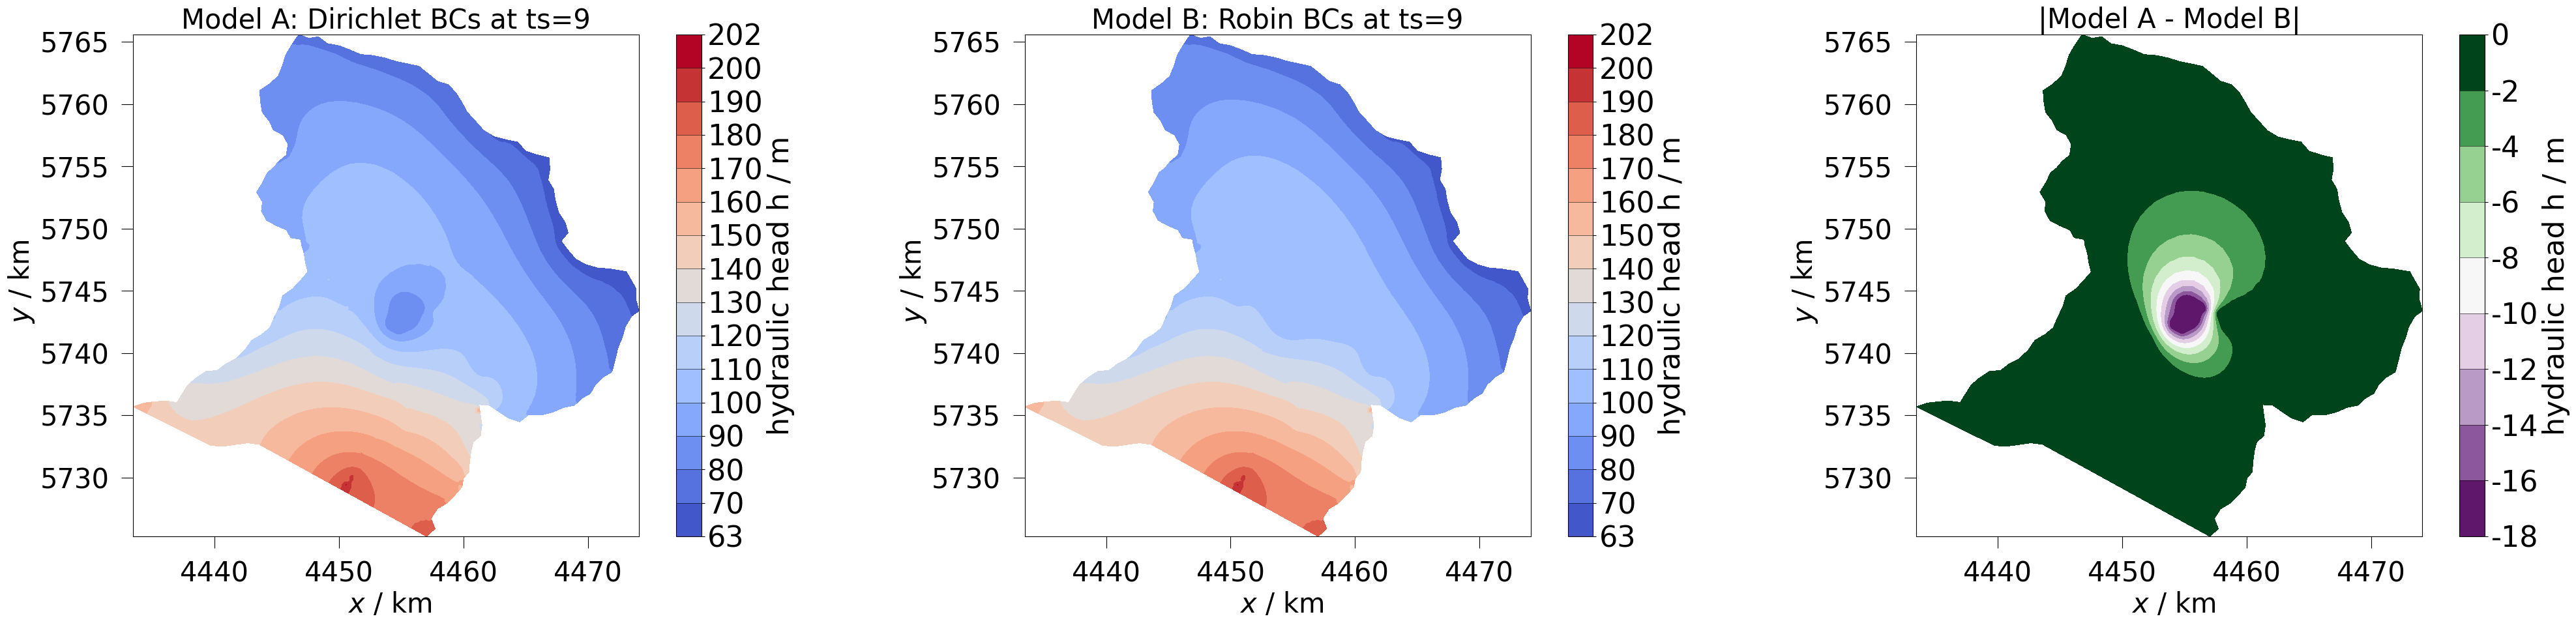

In [59]:
series_diff_robin = ot.MeshSeries.difference(ms_a=sim_recharge.meshseries, ms_b=sim_robin.meshseries)
month = 9
variable= "hydraulic head h / m"

# ################################
# Plotting
# ################################
fig, axs = plt.subplots(1, 3, figsize=(50,10))
ot.plot.contourf(sim_recharge.meshseries[month],variable, fig=fig, ax=axs[0])
add_isolines(sim_recharge.meshseries[month], variable, axs[0])
ot.plot.contourf(sim_robin.meshseries[month],variable, fig=fig, ax=axs[1])
add_isolines(sim_robin.meshseries[month], variable, axs[1])
ot.plot.contourf(series_diff_robin[month],variable, fig=fig, ax=axs[2],cmap="PRGn")
add_isolines(series_diff_robin[month], variable, axs[2])

axs[0].set_title(f"Model A: Dirichlet BCs at ts={month}")
axs[1].set_title(f"Model B: Robin BCs at ts={month}")
axs[2].set_title(
    r"|Model A - Model B|")
ot.plot.utils.update_font_sizes(axs, fontsize=30)